# 01 Data Exploration

## Goal

Understand the modeled event dataset, its grain, event mix, date coverage, and key data-quality caveats before calculating product metrics.

## Setup

Connect to the local DuckDB database created by the compact transformation pipeline.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd
import matplotlib.pyplot as plt

from product_growth_analytics.notebook_utils import connect, query_df

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)
con = connect()

## Data

Start with the compact modeled tables created from the raw Kaggle event logs.

In [2]:
tables = query_df(con, """
SELECT table_schema, table_name
FROM information_schema.tables
WHERE table_schema = 'analytics'
ORDER BY table_name
""")
tables

,table_schema,table_name
0,analytics,data_quality_summary
1,analytics,dataset_overview
2,analytics,event_type_summary
3,analytics,fact_purchases
4,analytics,mart_daily_growth_metrics
5,analytics,mart_monthly_growth_metrics
6,analytics,mart_product_funnel
7,analytics,mart_user_lifecycle
8,analytics,mart_weekly_growth_metrics
9,analytics,mart_weekly_user_activity


In [3]:
overview = query_df(con, """
SELECT *
FROM analytics.dataset_overview
""")
overview

,events,users,sessions,products,categories,category_codes,brands,min_event_time,max_event_time
0,109950743,5316649,23016650,206876,691,130,4304,2019-10-01,2019-11-30 23:59:59


## Results

Check the event mix. This tells us whether the dataset is mostly browsing, purchase, or intent behavior.

In [4]:
event_mix = query_df(con, """
SELECT
    event_type,
    events,
    users,
    events * 1.0 / SUM(events) OVER () AS event_share
FROM analytics.event_type_summary
ORDER BY events DESC
""")
event_mix

,event_type,events,users,event_share
0,view,104335509,5316128,0.9489
1,cart,3955446,1054133,0.0360
2,purchase,1659788,697470,0.0151


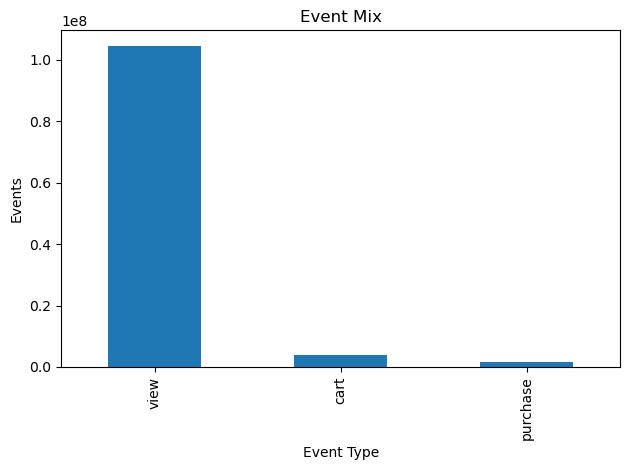

In [5]:
ax = event_mix.plot(kind="bar", x="event_type", y="events", legend=False, title="Event Mix")
ax.set_xlabel("Event Type")
ax.set_ylabel("Events")
plt.tight_layout()

## Checks

Review known quality flags that will affect future interpretation.

In [6]:
quality_flags = query_df(con, """
SELECT *
FROM analytics.data_quality_summary
""")
quality_flags

,unknown_category_rows,unknown_brand_rows,null_session_rows,negative_price_rows,zero_price_rows,anomaly_window_rows
0,35413780.0000,15331243.0000,12.0000,0.0000,256761.0000,19118750.0000


## Takeaways

- The modeled dataset contains **109,950,743 events** from **5,316,649 users**, **23,016,650 sessions**, and **206,876 products** across **October 1, 2019 to November 30, 2019**.
- The event mix is heavily top-of-funnel: **94.89% views**, **3.60% cart events**, and **1.51% purchases**. This makes the dataset especially useful for product funnel and lifecycle analysis.
- The product has a large browsing audience, but the share of users reaching cart and purchase is much smaller. Future notebooks should focus on conversion, repeat purchase, and retention rather than generic sales reporting.
- Key data caveats: **35,413,780 rows** have unknown category labels, **15,331,243 rows** have unknown brand labels, and **12 rows** have missing sessions.
- There are **256,761 zero-price rows**, but purchase revenue should still be calculated only from `purchase` events.
- The **November 15-17 anomaly window** affects **19,118,750 rows**, so daily purchase and revenue trends around those dates need annotation before making business claims.

Overall, the dataset is suitable for Product Growth Analytics, but the analysis needs clear denominator definitions and visible caveats around missing labels, limited time coverage, and the mid-November anomaly.